In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
### eample dataset taken from kaggle: https://www.kaggle.com/code/fahrulr/heart-failure-prediction?select=heart_failure_clinical_records_dataset.csv

df=pd.read_csv(r"C:\Users\ANT PC\Documents\GitHub\Deep-Learning\Graph Theory\HandsonGNN\heart_failure_clinical_records_dataset.csv")

In [3]:
df.head(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


In [4]:
continuous_feat=["age","creatinine_phosphokinase","ejection_fraction","platelets","serum_creatinine","serum_sodium","time"]
categorical_feat=["anaemia","diabetes","high_blood_pressure","sex","smoking"]

#### Pearson Spearman

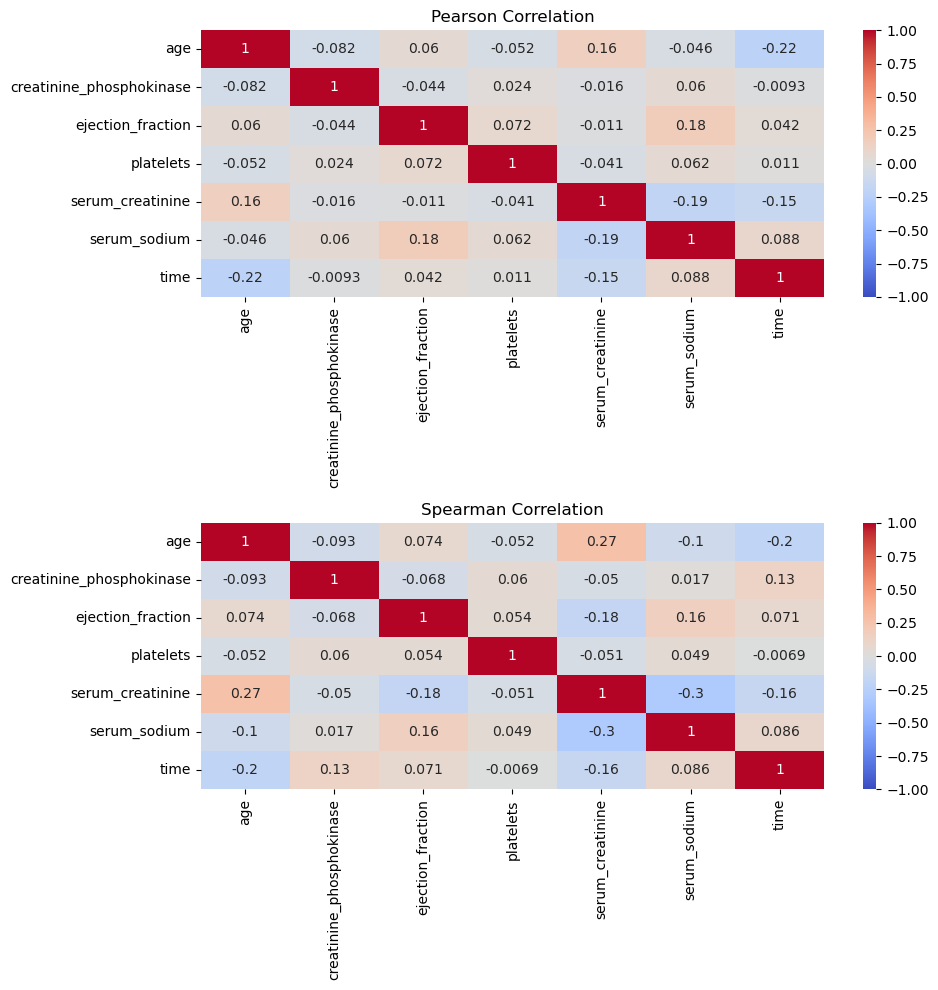

In [6]:
df_numeric = df[continuous_feat]

# Calculate Pearson and Spearman correlation matrices
pearson_corr = df_numeric.corr(method='pearson')
spearman_corr = df_numeric.corr(method='spearman')

# Plot settings
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Pearson heatmap
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation')

# Spearman heatmap
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation')

plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import chi2_contingency
import itertools

In [8]:
def cramers_v(confusion_matrix):
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan

#### Chisquare test

In [10]:
results = []
for col1, col2 in itertools.combinations(categorical_feat, 2):
    contingency_table = pd.crosstab(df[col1], df[col2])
    
    # Check for empty or invalid tables
    if contingency_table.size == 0 or contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        continue
    
    try:
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        v = cramers_v(contingency_table)
        results.append({
            'Var1': col1,
            'Var2': col2,
            'Chi2': round(chi2, 4),
            'p-value': round(p, 4),
            "Cramér's V": round(v, 4),
            'dof': dof,
            'Significant': 'Yes' if p < 0.05 else 'No'
        })
    except Exception as e:
        print(f"Skipped pair ({col1}, {col2}) due to error: {e}")

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
results_df.sort_values('p-value')

,Var1,Var2,Chi2,p-value,Cramér's V,dof,Significant
9,sex,smoking,57.4631,0.0000,0.4384,1,Yes
5,diabetes,sex,6.7839,0.0092,0.1506,1,Yes
6,diabetes,smoking,5.8530,0.0156,0.1399,1,Yes
3,anaemia,smoking,2.9935,0.0836,0.1001,1,No
7,high_blood_pressure,sex,2.8293,0.0926,0.0973,1,No
2,anaemia,sex,2.2995,0.1294,0.0877,1,No
8,high_blood_pressure,smoking,0.6949,0.4045,0.0482,1,No
1,anaemia,high_blood_pressure,0.2894,0.5906,0.0311,1,No
0,anaemia,diabetes,0.0104,0.9190,0.0059,1,No
4,diabetes,high_blood_pressure,0.0095,0.9224,0.0056,1,No
